In [1]:
import sys
import os
from functools import partial

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from src.factors import calculate_pe_ratio
from src.data_loader import load_prices
from src.factors import zscore_factor, calculate_momentum
from src.backtest import (
    momentum_low_vol_score,
    momentum_score,
    momentum_value_score,
    run_factor_backtest,
)
from src.experiment import parameter_sensitivity_analysis
from src.metrics import calculate_performance_metrics
from src.visualization import plot_parameter_sensitivity


In [2]:
prices = load_prices()
# Get the list of tickers
tickers = prices.columns.tolist()

tickers

['AAPL',
 'AMGN',
 'AMZN',
 'AXP',
 'BA',
 'CAT',
 'CRM',
 'CSCO',
 'CVX',
 'DIS',
 'GS',
 'HD',
 'HON',
 'IBM',
 'JNJ',
 'JPM',
 'KO',
 'MCD',
 'MMM',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PG',
 'SHW',
 'TRV',
 'UNH',
 'V',
 'VZ',
 'WMT']

In [3]:
# Calculate the P/E ratio for each ticker
pe = calculate_pe_ratio(

    tickers

)

pe

AAPL    34.355930
AMGN    24.935978
AMZN    31.658504
AXP     21.232687
BA      86.210320
CAT     49.749126
CRM     18.351100
CSCO    37.923332
CVX     29.749565
DIS     15.806400
GS      18.623013
HD      24.759403
HON     18.517544
IBM     24.038054
JNJ     29.508690
JPM     15.751555
KO      25.984276
MCD     22.220758
MMM     31.662163
MRK     36.242256
MSFT    22.227055
NKE     26.809212
NVDA    29.483920
PG      21.786550
SHW     32.988495
TRV      9.766408
UNH     32.269230
V       29.313862
VZ      11.351220
WMT     40.879860
dtype: float64

In [4]:
pe.describe()

count    30.000000
mean     28.471882
std      13.992797
min       9.766408
25%      21.371153
50%      26.396744
75%      32.117463
max      86.210320
dtype: float64

In [5]:
# Sort the P/E ratios in descending order
pe.sort_values(ascending=False)

BA      86.210320
CAT     49.749126
WMT     40.879860
CSCO    37.923332
MRK     36.242256
AAPL    34.355930
SHW     32.988495
UNH     32.269230
MMM     31.662163
AMZN    31.658504
CVX     29.749565
JNJ     29.508690
NVDA    29.483920
V       29.313862
NKE     26.809212
KO      25.984276
AMGN    24.935978
HD      24.759403
IBM     24.038054
MSFT    22.227055
MCD     22.220758
PG      21.786550
AXP     21.232687
GS      18.623013
HON     18.517544
CRM     18.351100
DIS     15.806400
JPM     15.751555
VZ      11.351220
TRV      9.766408
dtype: float64

In [6]:
# Calculate the z-score of the P/E ratios
value_z = zscore_factor(-pe)

# Create a DataFrame to display the P/E ratios and their corresponding z-scores
value_factor_table = pd.DataFrame({
    "P/E": pe,
    "Value Z": value_z
})


value_factor_table.sort_values(
    "Value Z",
    ascending=False
)


,P/E,Value Z
TRV,9.766408,1.336793
VZ,11.351220,1.223534
JPM,15.751555,0.909063
DIS,15.806400,0.905143
CRM,18.351100,0.723285
HON,18.517544,0.711390
GS,18.623013,0.703853
AXP,21.232687,0.517352
PG,21.786550,0.477770
MCD,22.220758,0.446739


In [7]:
#Recreate the momentum factor and calculate its z-score
momentum = calculate_momentum(prices, lookback=252)

latest_momentum = momentum.iloc[-1]
momentum_z = zscore_factor(latest_momentum)

# Create a DataFrame to compare the z-scores of the momentum and value factors
comparison = pd.DataFrame({
    "Momentum Z": momentum_z,
    "Value Z": value_z
}).dropna()

comparison.corr()

,Momentum Z,Value Z
Momentum Z,1.000000,0.194587
Value Z,0.194587,1.000000


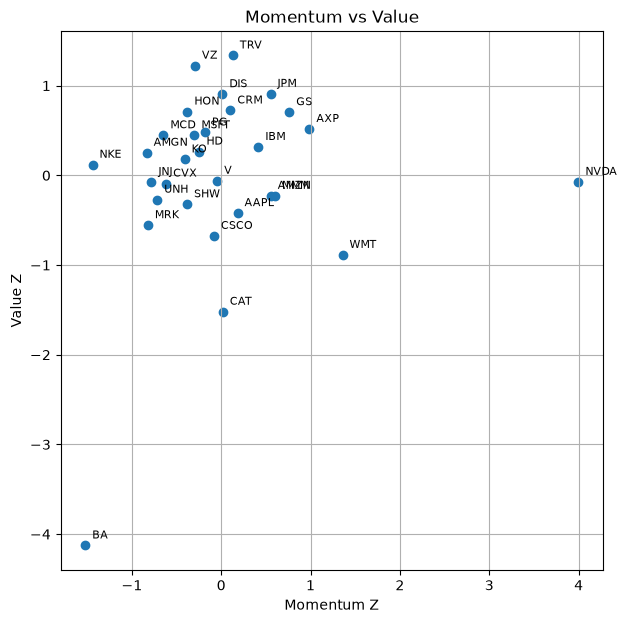

In [8]:
# Create a scatter plot to visualize the relationship between the momentum and value factors
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    comparison["Momentum Z"],
    comparison["Value Z"]
)

for ticker in comparison.index:

    ax.annotate(

        ticker,

        (

            comparison.loc[ticker, "Momentum Z"],

            comparison.loc[ticker, "Value Z"]

        ),

        xytext=(5, 5),

        textcoords="offset points",

        fontsize=8

    )

ax.set_xlabel("Momentum Z")
ax.set_ylabel("Value Z")
ax.set_title("Momentum vs Value")

ax.grid(True)

plt.show()

In [9]:
pearson_corr = comparison["Momentum Z"].corr(
    comparison["Value Z"]
)

spearman_corr = (
    comparison["Momentum Z"]
    .rank()
    .corr(
        comparison["Value Z"].rank()
    )
)

print(pearson_corr)
print(spearman_corr)

0.19458703319919346
0.17597330367074526


In [10]:
portfolio, holdings = run_factor_backtest(

    prices,

    score_function=lambda current_prices, current_returns, formation_date:

        momentum_value_score(

            current_prices=current_prices,

            current_returns=current_returns,

            formation_date=formation_date,

            value_z=value_z,

            momentum_weight=0.5,

            value_weight=0.5

        ),

    top_n=5,

    strategy_name="Momentum + Value"

)
portfolio.head()

2019-02-28    0.051620
2019-03-31    0.015893
2019-04-30    0.020544
2019-05-31   -0.050006
2019-06-30    0.058896
Name: Momentum + Value, dtype: float64

In [11]:
momentum_value_metrics = calculate_performance_metrics(
    portfolio
)

momentum_value_metrics

CAGR                 0.222898
Annual Return        0.219911
Annual Volatility    0.202920
Sharpe Ratio         1.083732
Max Drawdown        -0.234829
dtype: float64

In [12]:
# Recreate the momentum metrics for comparison
momentum_portfolio, momentum_holdings = run_factor_backtest(
    prices,
    score_function=partial(momentum_score, lookback=252),
    top_n=5,
    strategy_name="Momentum Strategy",
)

momentum_metrics = calculate_performance_metrics(momentum_portfolio)

# Recreate the momentum + low-volatility metrics for comparison
multi_portfolio, multi_holdings = run_factor_backtest(
    prices,
    score_function=partial(
        momentum_low_vol_score,
        lookback=252,
        vol_window=252,
        momentum_weight=0.5,
        low_vol_weight=0.5,
    ),
    top_n=5,
    strategy_name="Momentum + Low Vol",
)

multi_metrics = calculate_performance_metrics(multi_portfolio)

# Recreate the SPY benchmark metrics for comparison
spy = yf.download(
    "SPY",
    start="2018-01-01",
    end="2025-01-01",
    auto_adjust=True,
)

spy_close = spy["Close"]["SPY"] if isinstance(spy["Close"], pd.DataFrame) else spy["Close"]
spy_returns = spy_close.resample("ME").last().pct_change().loc[portfolio.index]
spy_metrics = calculate_performance_metrics(spy_returns)


[*********************100%***********************]  1 of 1 completed


In [13]:
comparison_value = pd.DataFrame({
    "Momentum": momentum_metrics,
    "Momentum + Low Vol": multi_metrics,
    "Momentum + Value": momentum_value_metrics,
    "SPY": spy_metrics
})

comparison_value


,Momentum,Momentum + Low Vol,Momentum + Value,SPY
CAGR,0.230520,0.139358,0.222898,0.160590
Annual Return,0.225387,0.145261,0.219911,0.162722
Annual Volatility,0.198403,0.180922,0.202920,0.173038
Sharpe Ratio,1.136003,0.802892,1.083732,0.940384
Max Drawdown,-0.177543,-0.134916,-0.234829,-0.239272


In [14]:
def run_momentum_value_factor_backtest(
    prices,
    momentum_weight,
    value_weight,
):
    return run_factor_backtest(
        prices,
        score_function=partial(
            momentum_value_score,
            value_z=value_z,
            momentum_weight=momentum_weight,
            value_weight=value_weight,
            lookback=252,
        ),
        top_n=5,
        strategy_name="Momentum + Value",
    )


# Run parameter sensitivity analysis
value_results, value_portfolios = parameter_sensitivity_analysis(
    prices=prices,
    backtest_function=run_momentum_value_factor_backtest,
    factor_1_name="Momentum",
    factor_2_name="Value",
    factor_1_weight_name="momentum_weight",
    factor_2_weight_name="value_weight",
)
value_results.to_csv("../data/momentum_value_weight_tuning.csv", index=False)
value_results


,Momentum Weight,Value Weight,CAGR,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
0,0.0,1.0,0.119586,0.132119,0.202627,0.652032,-0.327612
1,0.1,0.9,0.110850,0.124904,0.205497,0.607816,-0.290083
2,0.2,0.8,0.145113,0.154873,0.204244,0.758272,-0.352757
3,0.3,0.7,0.162160,0.168345,0.198380,0.848597,-0.325617
4,0.4,0.6,0.185879,0.189099,0.202506,0.933795,-0.269944
5,0.5,0.5,0.222898,0.219911,0.202920,1.083732,-0.234829
6,0.6,0.4,0.257164,0.248007,0.205270,1.208198,-0.198432
7,0.7,0.3,0.230757,0.227722,0.210998,1.079262,-0.201366
8,0.8,0.2,0.185142,0.186229,0.190396,0.978116,-0.188422
9,0.9,0.1,0.208355,0.206116,0.192882,1.068610,-0.193758


In [15]:
# Sort results by CAGR
value_results.sort_values(
    "CAGR",
    ascending=False
)


,Momentum Weight,Value Weight,CAGR,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
6,0.6,0.4,0.257164,0.248007,0.205270,1.208198,-0.198432
7,0.7,0.3,0.230757,0.227722,0.210998,1.079262,-0.201366
10,1.0,0.0,0.230520,0.225387,0.198403,1.136003,-0.177543
5,0.5,0.5,0.222898,0.219911,0.202920,1.083732,-0.234829
9,0.9,0.1,0.208355,0.206116,0.192882,1.068610,-0.193758
4,0.4,0.6,0.185879,0.189099,0.202506,0.933795,-0.269944
8,0.8,0.2,0.185142,0.186229,0.190396,0.978116,-0.188422
3,0.3,0.7,0.162160,0.168345,0.198380,0.848597,-0.325617
2,0.2,0.8,0.145113,0.154873,0.204244,0.758272,-0.352757
0,0.0,1.0,0.119586,0.132119,0.202627,0.652032,-0.327612


In [16]:
# Sort results by Sharpe Ratio
value_results.sort_values(
    "Sharpe Ratio",
    ascending=False
)


,Momentum Weight,Value Weight,CAGR,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown
6,0.6,0.4,0.257164,0.248007,0.205270,1.208198,-0.198432
10,1.0,0.0,0.230520,0.225387,0.198403,1.136003,-0.177543
5,0.5,0.5,0.222898,0.219911,0.202920,1.083732,-0.234829
7,0.7,0.3,0.230757,0.227722,0.210998,1.079262,-0.201366
9,0.9,0.1,0.208355,0.206116,0.192882,1.068610,-0.193758
8,0.8,0.2,0.185142,0.186229,0.190396,0.978116,-0.188422
4,0.4,0.6,0.185879,0.189099,0.202506,0.933795,-0.269944
3,0.3,0.7,0.162160,0.168345,0.198380,0.848597,-0.325617
2,0.2,0.8,0.145113,0.154873,0.204244,0.758272,-0.352757
0,0.0,1.0,0.119586,0.132119,0.202627,0.652032,-0.327612


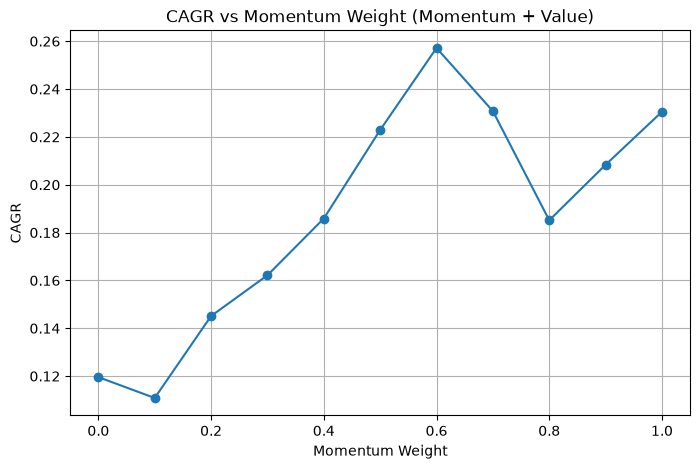

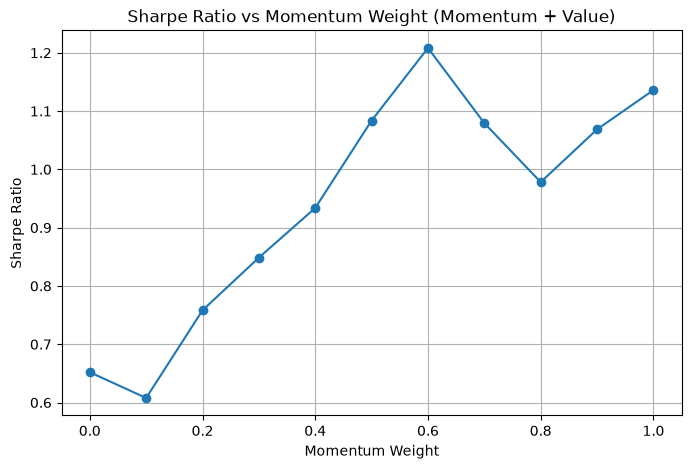

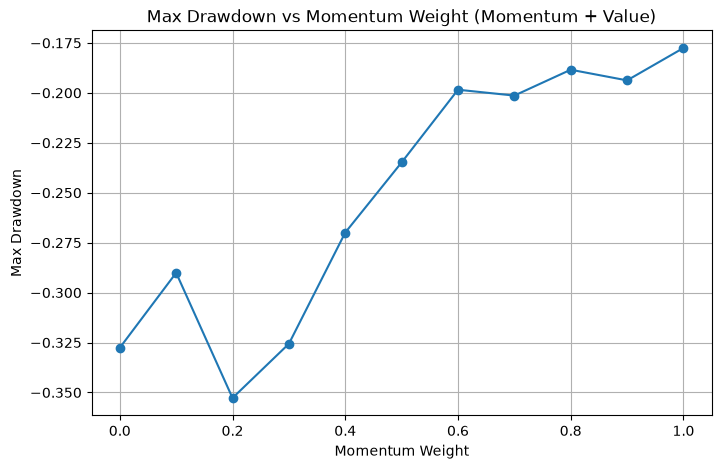

In [17]:
# Plot parameter sensitivity results
plot_parameter_sensitivity(
    value_results,
    "CAGR",
    title="CAGR vs Momentum Weight (Momentum + Value)"
)
plot_parameter_sensitivity(
    value_results,
    "Sharpe Ratio",
    title="Sharpe Ratio vs Momentum Weight (Momentum + Value)"
)
plot_parameter_sensitivity(
    value_results,
    "Max Drawdown",
    title="Max Drawdown vs Momentum Weight (Momentum + Value)"
)




A moderate Value allocation improved the Momentum strategy, with the 60% Momentum / 40% Value portfolio achieving the highest Sharpe ratio and CAGR among tested combinations.
